# Time-aware forecasting report: regularized linear models and XGBoost

This notebook implements a leakage-resistant forecasting workflow for
`ncliGrowthNextYear` using the German firm-year panel.

It applies the main changes identified in the previous review:

- a strict **2010–2019 development / 2020–2023 held-out test** split;
- five **expanding-window** validation folds inside the development period;
- preprocessing fitted separately inside every validation fold;
- time-aware tuning of **Ridge, Lasso and Elastic Net**;
- time-aware tuning of **XGBoost**, using shallow trees and early stopping;
- no Random Forest, because that model is handled by another project member;
- explicit feature blocks for **firm fundamentals**, **survey indicators**, and
  **text indicators**;
- feature-ablation comparisons that directly test whether survey and text
  indicators improve forecasts;
- safer balance-sheet ratios, stable macro changes, and no full-sample
  winsorization;
- pooled and year-specific test results, plus benchmark forecasts.

## Before running

1. Adjust `DATA_PATH` in the configuration cell if necessary.
2. Start with `QUICK_MODE = True` to test the pipeline.
3. For the final paper, restart the kernel, set `QUICK_MODE = False`, run all
   cells, and avoid changing the specification after viewing the held-out test
   results.

## 1. Imports and configuration

In [3]:
from __future__ import annotations

import gc
import json
import os
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, ParameterSampler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import xgboost as xgb

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
DATA_PATH = Path("data/model_input/analysis_panel.parquet")
OUTPUT_DIR = Path("outputs/time_aware_model_report")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Reproducibility and evaluation design
# -----------------------------------------------------------------------------
RANDOM_STATE = 42
YEAR_COL = "closdate_year"
ID_COL = "idnr"
TARGET = "ncliGrowthNextYear"
TEST_START_YEAR = 2020
TEST_YEARS = [2020, 2021, 2022, 2023]
MIN_TRAIN_YEARS = 5  # train 2010-2014 -> validate 2015, ..., validate 2019

# -----------------------------------------------------------------------------
# Runtime controls
# -----------------------------------------------------------------------------
# QUICK_MODE uses a deterministic year-stratified subsample for tuning only.
# Final refits still use every development observation.
QUICK_MODE = True
TUNING_MAX_ROWS_PER_YEAR = 15_000 if QUICK_MODE else 50_000
XGB_TUNING_TRIALS = 4 if QUICK_MODE else 15
XGB_MAX_ESTIMATORS = 800 if QUICK_MODE else 1_500
XGB_EARLY_STOPPING_ROUNDS = 40 if QUICK_MODE else 75
PERMUTATION_SAMPLE_SIZE = 20_000 if QUICK_MODE else 50_000

# Keep parallelism conservative to avoid duplicating the large dataset in RAM.
LINEAR_SEARCH_N_JOBS = 1
XGB_N_JOBS = max(1, min(4, os.cpu_count() or 1))

# Set to False while iterating on code. Set to True only after the specification
# and hyperparameters have been selected using development-period CV.
RUN_FINAL_TEST = True
SAVE_MODELS = False

print({
    "quick_mode": QUICK_MODE,
    "tuning_max_rows_per_year": TUNING_MAX_ROWS_PER_YEAR,
    "xgb_tuning_trials": XGB_TUNING_TRIALS,
    "xgb_threads": XGB_N_JOBS,
    "run_final_test": RUN_FINAL_TEST,
})

{'quick_mode': True, 'tuning_max_rows_per_year': 15000, 'xgb_tuning_trials': 4, 'xgb_threads': 4, 'run_final_test': True}


### Computational note

The full panel is large. Hyperparameter selection and cross-validation use a
deterministic cap per year; final models are still refitted on every 2010–2019
observation. Quick mode uses 15,000 rows per year and full mode 50,000. Set
`TUNING_MAX_ROWS_PER_YEAR = None` only when sufficient time and memory are
available. Numeric variables are standardized; one-hot dummies remain 0/1 to
avoid unstable rescaling of rare categories.

## 2. Load the Parquet panel efficiently

In [4]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.resolve()}. Adjust DATA_PATH in Section 1."
    )

DROP_COLS_AT_LOAD = ["name", "dateinc", "report_date"]
schema_cols = pq.ParquetFile(DATA_PATH).schema_arrow.names
usecols = [c for c in schema_cols if c not in DROP_COLS_AT_LOAD]

df = pd.read_parquet(DATA_PATH, columns=usecols)

required = {ID_COL, YEAR_COL, TARGET}
missing_required = sorted(required.difference(df.columns))
if missing_required:
    raise KeyError(f"Required columns are missing: {missing_required}")

float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")

df[YEAR_COL] = pd.to_numeric(df[YEAR_COL], errors="coerce").astype("Int16")
df = df.dropna(subset=[ID_COL, YEAR_COL, TARGET]).copy()
df[YEAR_COL] = df[YEAR_COL].astype(int)

gc.collect()
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
df.head()

Shape: (1745282, 77)
Memory usage: 0.69 GB


,lm_positive,lm_negative,lm_polarity,uncertainty_ratio,litigious_ratio,constraining_ratio,strong_modal_ratio,weak_modal_ratio,ifo_business_climate,ifo_business_situation,ifo_business_expectations,de_economic_sentiment_index,de_employment_expectations_index,de_industry_confidence,de_services_confidence,de_consumer_confidence,de_retail_confidence,de_construction_confidence,year,ifo_business_climate_growth,ifo_business_situation_growth,ifo_business_expectations_growth,de_economic_sentiment_index_growth,de_employment_expectations_index_growth,de_industry_confidence_growth,de_services_confidence_growth,de_consumer_confidence_growth,de_retail_confidence_growth,de_construction_confidence_growth,idnr,type,naics_core_code,closdate_year,empl,ncliGrowthNextYear,fias,ifas,tfas,ofas,cuas,stok,debt,ocas,cash,toas,shfd,capi,osfd,ncli,ltdb,oncl,prov,culi,loan,cred,ocli,tshf,wkca,leverage,gearing,solvency,current_ratio,quick_ratio,cash_ratio,inventory_share,receivables_share,working_capital_ratio,log_toas,log_empl,ncliGrowthThisYear,toas_growth,cash_growth,growth_volatility,firm_age,years_in_panel,naics_2digit,is_na_empl
0,265,402,-0.205397,0.020557,0.014647,0.003769,0.001970,0.006167,98.199997,98.400002,98.099998,103.000000,102.099998,-4.4,12.300000,-1.4,-11.2,-11.4,2014,2.291667,2.393340,2.294056,0.684262,2.202202,-2.222222,7.894737,-26.315790,-15.151515,-10.236220,DE2010353555,Limited liability company - GmbH,4247,2014,60.0,0.384772,1116330.0,58274.0,1032556.0,25500.0,5473217.0,629038.0,3433723.0,1410457.0,642453.0,6589548.0,340819.0,300000.0,40819.0,530748.0,438352.0,92396.0,92396.0,5717980.0,279973.0,4845287.0,592720.0,6589548.0,-782527.0,0.080544,2.378744,0.051721,0.957194,0.847184,0.097496,0.095460,0.448893,-0.118054,15.700995,4.110874,NaN,NaN,NaN,NaN,24.0,0,42,0
1,301,447,-0.195187,0.018509,0.033679,0.014682,0.001600,0.004593,100.699997,100.599998,100.800003,106.400002,109.800003,-3.0,19.600000,-1.8,-2.5,-5.3,2015,-0.297030,0.099502,-0.787402,-0.467727,0.733945,15.384615,-8.837210,-45.454544,257.142853,-1.851852,DE2010353555,Limited liability company - GmbH,4247,2015,52.0,-0.401733,1040340.0,57800.0,952040.0,30500.0,5401788.0,540662.0,3050158.0,1810968.0,946953.0,6442129.0,634808.0,300000.0,334808.0,734965.0,492314.0,242651.0,242651.0,5072355.0,283886.0,4225698.0,562771.0,6442129.0,-634878.0,0.114087,1.604975,0.098540,1.064947,0.958357,0.146994,0.083926,0.448893,-0.098551,15.678370,3.970292,0.384772,-0.022372,0.473965,NaN,25.0,1,42,0
2,352,677,-0.315841,0.021990,0.012566,0.005463,0.002117,0.005600,101.000000,101.800003,100.199997,109.400002,112.099998,2.5,20.299999,-0.3,-4.0,5.5,2016,-0.590551,-0.391389,-0.792079,1.390176,0.358102,733.333313,7.407407,-66.666664,37.931034,150.000000,DE2010353555,Limited liability company - GmbH,4247,2016,49.0,0.816768,1286081.0,34945.0,1220636.0,30500.0,5791927.0,437567.0,3559991.0,1794370.0,964097.0,7078008.0,559668.0,300000.0,259668.0,439705.0,272022.0,167683.0,167683.0,6078635.0,220435.0,5323352.0,534848.0,7078008.0,-1325795.0,0.062123,1.179521,0.079071,0.952833,0.880849,0.136210,0.061821,0.448893,-0.118054,15.772503,3.912023,-0.401733,0.098706,0.018104,0.556143,26.0,2,42,0
3,397,547,-0.158898,0.016656,0.015763,0.006186,0.002141,0.004342,104.699997,107.099998,102.500000,114.900002,116.900002,14.5,21.500000,1.4,0.1,12.3,2017,-0.285714,0.469043,-0.870406,0.612960,2.453988,9.022556,3.365385,-6.666667,-104.545456,1.652893,DE2010353555,Limited liability company - GmbH,4247,2017,49.0,-0.247863,1151630.0,33402.0,1072728.0,45500.0,5822139.0,379907.0,3151085.0,2291146.0,1558041.0,6973769.0,488143.0,300000.0,188143.0,798842.0,648201.0,150641.0,150641.0,5686783.0,297649.0,4887944.0,501190.0,6973769.0,-1356952.0,0.114550,2.246250,0.069997,1.023802,0.956997,0.223414,0.054477,0.448893,-0.118054,15.757667,3.912023,0.816768,-0.014727,0.616062,0.617786,27.0,3,42,0
4,359,513,-0.176606,0.020424,0.012030,0.006295,0.002518,0.004337,101.199997,105.300003,97.300003,110.199997,115.699997,3.9,21.600000,-0.8,-5.0,18.9,2018,-1

## 3. Data-integrity checks

In [5]:
year_counts = df[YEAR_COL].value_counts().sort_index()
duplicate_firm_years = int(df.duplicated([ID_COL, YEAR_COL]).sum())

print("Observations by fiscal year:")
display(year_counts.to_frame("n"))
print(f"Duplicate firm-years: {duplicate_firm_years:,}")
print("Target summary:")
display(df[TARGET].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame().T)

# Accounting identity audit. These checks do not alter the data.
def relative_gap(a: pd.Series, b: pd.Series) -> pd.Series:
    denom = np.maximum(np.maximum(a.abs(), b.abs()), 1.0)
    return (a - b).abs() / denom

audit_rows = []
if {"toas", "tshf"}.issubset(df.columns):
    gap = relative_gap(df["toas"], df["tshf"])
    audit_rows.append({
        "identity": "toas = tshf",
        "median_relative_gap": float(gap.median()),
        "p99_relative_gap": float(gap.quantile(0.99)),
        "share_gap_gt_1pct": float((gap > 0.01).mean()),
    })
if {"fias", "cuas", "toas"}.issubset(df.columns):
    gap = relative_gap(df["fias"] + df["cuas"], df["toas"])
    audit_rows.append({
        "identity": "fias + cuas = toas",
        "median_relative_gap": float(gap.median()),
        "p99_relative_gap": float(gap.quantile(0.99)),
        "share_gap_gt_1pct": float((gap > 0.01).mean()),
    })
if {"shfd", "ncli", "culi", "tshf"}.issubset(df.columns):
    gap = relative_gap(df["shfd"] + df["ncli"] + df["culi"], df["tshf"])
    audit_rows.append({
        "identity": "shfd + ncli + culi = tshf",
        "median_relative_gap": float(gap.median()),
        "p99_relative_gap": float(gap.quantile(0.99)),
        "share_gap_gt_1pct": float((gap > 0.01).mean()),
    })

if audit_rows:
    display(pd.DataFrame(audit_rows))

Observations by fiscal year:


,n
closdate_year,
2010,13132
2011,12950
2012,21695
2013,39951
2014,138297
2015,145276
2016,149169
2017,190184
2018,201605


Duplicate firm-years: 0
Target summary:


,count,mean,std,min,1%,5%,50%,95%,99%,max
ncliGrowthNextYear,1745282.0,-0.056992,0.389922,-1.0,-0.97015,-0.799286,-0.041829,0.640229,0.907659,0.999999


,identity,median_relative_gap,p99_relative_gap,share_gap_gt_1pct
0,toas = tshf,0.0,0.000000,0.000000
1,fias + cuas = toas,0.0,0.000002,0.000158
2,shfd + ncli + culi = tshf,0.0,0.000004,0.000002


The accounting audit is diagnostic. Large discrepancies may indicate missing
components, different statement definitions, or upstream unit problems. Ratios
below are only calculated where their denominators and component relationships
are economically meaningful.

## 4. Leakage-safe feature engineering

In [6]:
def safe_ratio(
    numerator: pd.Series,
    denominator: pd.Series,
    *,
    require_positive_denominator: bool = True,
) -> pd.Series:
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = numerator.notna() & denominator.notna()
    if require_positive_denominator:
        valid &= denominator > 0
    else:
        valid &= denominator != 0
    out = pd.Series(np.nan, index=numerator.index, dtype="float32")
    out.loc[valid] = (numerator.loc[valid] / denominator.loc[valid]).astype("float32")
    return out.replace([np.inf, -np.inf], np.nan)

# Sort once so all lagged firm features use only t and earlier observations.
df = df.sort_values([ID_COL, YEAR_COL]).copy()
firm_group = df.groupby(ID_COL, sort=False)
lag_year = firm_group[YEAR_COL].shift(1)
consecutive = (df[YEAR_COL] - lag_year).eq(1)

# -----------------------------------------------------------------------------
# Ratios based on documented balance-sheet identities. No data-driven
# winsorization is used, so test-year values cannot influence training values.
# -----------------------------------------------------------------------------
if {"cuas", "culi"}.issubset(df.columns):
    df["current_ratio_clean"] = safe_ratio(df["cuas"], df["culi"])
    df["log1p_current_ratio_clean"] = np.log1p(
        df["current_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"cuas", "stok", "culi"}.issubset(df.columns):
    quick_assets = df["cuas"] - df["stok"]
    df["quick_ratio_clean"] = safe_ratio(quick_assets, df["culi"])
    df["log1p_quick_ratio_clean"] = np.log1p(
        df["quick_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"shfd", "toas"}.issubset(df.columns):
    df["solvency_ratio_clean"] = safe_ratio(df["shfd"], df["toas"])

if {"ncli", "loan", "shfd"}.issubset(df.columns):
    # Gearing is undefined or difficult to interpret with non-positive equity.
    gearing_num = df["ncli"] + df["loan"]
    df["gearing_ratio_clean"] = safe_ratio(gearing_num, df["shfd"])
    df["log1p_gearing_ratio_clean"] = np.log1p(
        df["gearing_ratio_clean"].clip(lower=0)
    ).astype("float32")

if {"ncli", "culi", "toas"}.issubset(df.columns):
    df["liabilities_to_assets"] = safe_ratio(df["ncli"] + df["culi"], df["toas"])

if {"wkca", "toas"}.issubset(df.columns):
    df["working_capital_to_assets"] = safe_ratio(
        df["wkca"], df["toas"], require_positive_denominator=True
    )

if {"stok", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["stok"] >= 0) & (df["stok"] <= df["cuas"])
    df["inventory_share_current_assets"] = np.where(
        valid, df["stok"] / df["cuas"], np.nan
    ).astype("float32")

if {"debt", "cuas"}.issubset(df.columns):
    valid = (df["cuas"] > 0) & (df["debt"] >= 0) & (df["debt"] <= df["cuas"])
    df["receivables_share_current_assets"] = np.where(
        valid, df["debt"] / df["cuas"], np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["cash"] >= 0) & (df["cash"] <= df["toas"])
    df["cash_to_assets"] = np.where(valid, df["cash"] / df["toas"], np.nan).astype("float32")

if {"fias", "toas"}.issubset(df.columns):
    valid = (df["toas"] > 0) & (df["fias"] >= 0) & (df["fias"] <= df["toas"])
    df["fixed_assets_share"] = np.where(valid, df["fias"] / df["toas"], np.nan).astype("float32")

if {"ltdb", "ncli"}.issubset(df.columns):
    valid = (df["ncli"] > 0) & (df["ltdb"] >= 0) & (df["ltdb"] <= df["ncli"])
    df["ltdb_share_of_ncli"] = np.where(valid, df["ltdb"] / df["ncli"], np.nan).astype("float32")

# -----------------------------------------------------------------------------
# Stable changes in firm levels. These replace unstable cash percentage growth
# and make the time direction explicit.
# -----------------------------------------------------------------------------
if "log_toas" not in df.columns and "toas" in df.columns:
    df["log_toas"] = np.log1p(df["toas"].clip(lower=0)).astype("float32")
if "log_empl" not in df.columns and "empl" in df.columns:
    df["log_empl"] = np.log1p(df["empl"].clip(lower=0)).astype("float32")

if "log_toas" in df.columns:
    lag_log_toas = firm_group["log_toas"].shift(1)
    df["log_toas_change_clean"] = np.where(
        consecutive, df["log_toas"] - lag_log_toas, np.nan
    ).astype("float32")

if {"cash", "toas"}.issubset(df.columns):
    lag_cash = firm_group["cash"].shift(1)
    lag_toas = firm_group["toas"].shift(1)
    valid = consecutive & lag_toas.gt(0)
    df["cash_change_to_lagged_assets"] = np.where(
        valid, (df["cash"] - lag_cash) / lag_toas, np.nan
    ).astype("float32")

if "ncliGrowthThisYear" in df.columns:
    rolling_volatility = (
        df.groupby(ID_COL, sort=False)["ncliGrowthThisYear"]
          .rolling(window=3, min_periods=2)
          .std()
          .reset_index(level=0, drop=True)
    )
    df["ncli_growth_volatility_3y"] = rolling_volatility.astype("float32")

# -----------------------------------------------------------------------------
# Macro transformations.
# Confidence balances can cross zero, so use first differences.
# Positive indices use percentage changes calculated from annual levels.
# -----------------------------------------------------------------------------
BALANCE_LEVELS = [
    "de_construction_confidence",
    "de_consumer_confidence",
    "de_industry_confidence",
    "de_retail_confidence",
    "de_services_confidence",
]
POSITIVE_INDEX_LEVELS = [
    "de_economic_sentiment_index",
    "de_employment_expectations_index",
    "ifo_business_climate",
    "ifo_business_expectations",
    "ifo_business_situation",
]

available_macro_levels = [
    c for c in BALANCE_LEVELS + POSITIVE_INDEX_LEVELS if c in df.columns
]
if available_macro_levels:
    annual_macro = (
        df.groupby(YEAR_COL, sort=True)[available_macro_levels]
          .median(numeric_only=True)
          .sort_index()
    )

    for col in [c for c in BALANCE_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_change_clean"
        year_values = annual_macro[col].diff()
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

    for col in [c for c in POSITIVE_INDEX_LEVELS if c in annual_macro.columns]:
        new_col = f"{col}_pct_change_clean"
        current = annual_macro[col]
        previous = current.shift(1)
        year_values = ((current / previous) - 1).where((current > 0) & (previous > 0))
        df[new_col] = df[YEAR_COL].map(year_values).astype("float32")

# -----------------------------------------------------------------------------
# Text counts are used only if a document-length variable exists. Otherwise,
# raw lm_positive/lm_negative counts are omitted and polarity/ratios are used.
# -----------------------------------------------------------------------------
TOKEN_COUNT_CANDIDATES = [
    "token_count", "n_tokens", "word_count", "total_words", "document_length"
]
token_count_col = next((c for c in TOKEN_COUNT_CANDIDATES if c in df.columns), None)
if token_count_col is not None:
    for source, target in [
        ("lm_positive", "lm_positive_frequency"),
        ("lm_negative", "lm_negative_frequency"),
    ]:
        if source in df.columns:
            df[target] = safe_ratio(df[source], df[token_count_col])
    print(f"Normalized sentiment counts using: {token_count_col}")
else:
    print("No document-length column found: raw positive/negative counts will be omitted.")

# Replace any remaining infinities and downcast new floating-point columns.
float64_cols = df.select_dtypes(include="float64").columns
df[float64_cols] = df[float64_cols].astype("float32")
df.replace([np.inf, -np.inf], np.nan, inplace=True)

del firm_group, lag_year, consecutive
gc.collect()

No document-length column found: raw positive/negative counts will be omitted.


0

### Feature-engineering audit

In [7]:
engineered_candidates = [
    "current_ratio_clean", "log1p_current_ratio_clean",
    "quick_ratio_clean", "log1p_quick_ratio_clean",
    "solvency_ratio_clean", "gearing_ratio_clean",
    "log1p_gearing_ratio_clean", "liabilities_to_assets",
    "working_capital_to_assets", "inventory_share_current_assets",
    "receivables_share_current_assets", "cash_to_assets",
    "fixed_assets_share", "ltdb_share_of_ncli",
    "log_toas_change_clean", "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y",
]
engineered_candidates += [
    f"{c}_change_clean" for c in BALANCE_LEVELS
] + [
    f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS
]
engineered_candidates += ["lm_positive_frequency", "lm_negative_frequency"]
engineered_present = [c for c in engineered_candidates if c in df.columns]

feature_audit = pd.DataFrame({
    "missing_share": df[engineered_present].isna().mean(),
    "n_unique": df[engineered_present].nunique(dropna=True),
    "min": df[engineered_present].min(numeric_only=True),
    "median": df[engineered_present].median(numeric_only=True),
    "max": df[engineered_present].max(numeric_only=True),
}).sort_values("missing_share")
display(feature_audit)

,missing_share,n_unique,min,median,max
liabilities_to_assets,0.000000,1666960,-0.124217,0.649108,7.342030e+05
solvency_ratio_clean,0.000000,1698084,-734202.000000,0.350892,1.124218e+00
fixed_assets_share,0.000018,1674087,0.000000,0.237142,1.000000e+00
ltdb_share_of_ncli,0.000128,1192410,0.000000,0.709300,1.000000e+00
de_retail_confidence_change_clean,0.007524,13,-18.400000,-1.000000,9.500000e+00
de_industry_confidence_change_clean,0.007524,13,-20.299999,1.400000,2.440000e+01
ifo_business_expectations_pct_change_clean,0.007524,13,-0.096591,-0.013727,6.827736e-02
ifo_business_situation_pct_change_clean,0.007524,13,-0.073663,-0.007064,6.100214e-02
ifo_business_climate_pct_change_clean,0.007524,13,-0.063941,-0.021912,5.241096e-02
de_employment_expectations_index_pct_change_clean,0.007524,13,-0.093345,-0.010265,1.725206e-01


## 5. Explicit feature blocks

In [8]:
def present(columns: list[str]) -> list[str]:
    return [c for c in columns if c in df.columns]

CATEGORY_COLS = present(["naics_2digit", "type"])

FIRM_NUMERIC_CANDIDATES = [
    "log_toas",
    "log_empl",                 # raw empl is intentionally omitted
    "firm_age",
    "years_in_panel",
    "is_na_empl",
    "ncliGrowthThisYear",
    "log_toas_change_clean",
    "cash_change_to_lagged_assets",
    "ncli_growth_volatility_3y",
    "log1p_current_ratio_clean",
    "log1p_quick_ratio_clean",
    "solvency_ratio_clean",
    "log1p_gearing_ratio_clean",
    "liabilities_to_assets",
    "working_capital_to_assets",
    "inventory_share_current_assets",
    "receivables_share_current_assets",
    "cash_to_assets",
    "fixed_assets_share",
    "ltdb_share_of_ncli",
]
FIRM_FEATURES = present(FIRM_NUMERIC_CANDIDATES) + CATEGORY_COLS

SURVEY_LEVEL_FEATURES = present(BALANCE_LEVELS + POSITIVE_INDEX_LEVELS)
SURVEY_CHANGE_FEATURES = present(
    [f"{c}_change_clean" for c in BALANCE_LEVELS]
    + [f"{c}_pct_change_clean" for c in POSITIVE_INDEX_LEVELS]
)
SURVEY_FEATURES = SURVEY_LEVEL_FEATURES + SURVEY_CHANGE_FEATURES

TEXT_FEATURES = present([
    "lm_polarity",
    "uncertainty_ratio",
    "litigious_ratio",
    "constraining_ratio",
    "strong_modal_ratio",
    "weak_modal_ratio",
    "lm_positive_frequency",
    "lm_negative_frequency",
])

FEATURE_SETS = {
    "firm": FIRM_FEATURES,
    "firm_survey": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES)),
    "firm_survey_text": list(dict.fromkeys(FIRM_FEATURES + SURVEY_FEATURES + TEXT_FEATURES)),
}

for name, cols in FEATURE_SETS.items():
    if not cols:
        raise ValueError(f"Feature set {name!r} is empty.")
    print(f"{name:>18}: {len(cols):>3} columns")
    print(cols)

# Explicit leakage / redundancy guard.
FORBIDDEN_FEATURES = {
    TARGET, YEAR_COL, "year", ID_COL, "naics_core_code", "empl",
    "cash_growth", "toas_growth",
    "de_construction_confidence_growth", "de_consumer_confidence_growth",
    "de_industry_confidence_growth", "de_retail_confidence_growth",
    "de_services_confidence_growth",
    "lm_positive", "lm_negative",
}
for set_name, cols in FEATURE_SETS.items():
    overlap = sorted(set(cols).intersection(FORBIDDEN_FEATURES))
    if overlap:
        raise AssertionError(f"Forbidden features in {set_name}: {overlap}")

              firm:  22 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_assets_share', 'ltdb_share_of_ncli', 'naics_2digit', 'type']
       firm_survey:  42 columns
['log_toas', 'log_empl', 'firm_age', 'years_in_panel', 'is_na_empl', 'ncliGrowthThisYear', 'log_toas_change_clean', 'cash_change_to_lagged_assets', 'ncli_growth_volatility_3y', 'log1p_current_ratio_clean', 'log1p_quick_ratio_clean', 'solvency_ratio_clean', 'log1p_gearing_ratio_clean', 'liabilities_to_assets', 'working_capital_to_assets', 'inventory_share_current_assets', 'receivables_share_current_assets', 'cash_to_assets', 'fixed_asset

The text block intentionally excludes raw positive and negative word counts when
a document-length denominator is unavailable. The survey block replaces
percentage changes of zero-crossing confidence balances with first differences.

## 6. Development/test split and tuning sample

In [9]:
ALL_MODEL_FEATURES = FEATURE_SETS["firm_survey_text"]
df[ALL_MODEL_FEATURES] = df[ALL_MODEL_FEATURES].replace([np.inf, -np.inf], np.nan)

train_df = df[df[YEAR_COL] < TEST_START_YEAR].copy()
test_df = df[df[YEAR_COL].isin(TEST_YEARS)].copy()

if train_df.empty or test_df.empty:
    raise ValueError("Development or test set is empty. Check the year configuration.")

train_mean = float(train_df[TARGET].mean())
print(
    f"Development: {train_df.shape}, years {train_df[YEAR_COL].min()}-"
    f"{train_df[YEAR_COL].max()}"
)
print(
    f"Held-out test: {test_df.shape}, years {test_df[YEAR_COL].min()}-"
    f"{test_df[YEAR_COL].max()}"
)
print(f"Development mean outcome: {train_mean:.6f}")


def year_stratified_cap(
    frame: pd.DataFrame,
    year_col: str,
    max_rows_per_year: int | None,
    random_state: int,
) -> pd.DataFrame:
    if max_rows_per_year is None:
        return frame.reset_index(drop=True).copy()

    parts = []
    for year, group in frame.groupby(year_col, sort=True):
        n = min(len(group), max_rows_per_year)
        parts.append(group.sample(n=n, random_state=random_state + int(year)))
    return pd.concat(parts, ignore_index=True).sort_values(year_col).reset_index(drop=True)


tuning_df = year_stratified_cap(
    train_df,
    YEAR_COL,
    TUNING_MAX_ROWS_PER_YEAR,
    RANDOM_STATE,
)
print("Tuning observations by year:")
display(tuning_df[YEAR_COL].value_counts().sort_index().to_frame("n"))

Development: (1113369, 104), years 2010-2019
Held-out test: (631913, 104), years 2020-2023
Development mean outcome: -0.068890
Tuning observations by year:


,n
closdate_year,
2010,13132
2011,12950
2012,15000
2013,15000
2014,15000
2015,15000
2016,15000
2017,15000
2018,15000


## 7. Expanding-window folds and metrics

In [10]:
def rolling_origin_indices(
    frame: pd.DataFrame,
    year_col: str,
    min_train_years: int,
) -> list[tuple[np.ndarray, np.ndarray]]:
    years = sorted(frame[year_col].dropna().unique().tolist())
    if len(years) <= min_train_years:
        raise ValueError("Not enough development years for the requested CV design.")

    folds = []
    for i in range(min_train_years, len(years)):
        validation_year = years[i]
        train_years = years[:i]
        train_idx = np.flatnonzero(frame[year_col].isin(train_years).to_numpy())
        validation_idx = np.flatnonzero(frame[year_col].eq(validation_year).to_numpy())
        folds.append((train_idx, validation_idx))
    return folds


def regression_metrics(
    y_true: np.ndarray | pd.Series,
    y_pred: np.ndarray | pd.Series,
    baseline_value: float,
) -> dict[str, float]:
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[valid], yp[valid]
    if len(yt) == 0:
        return {"RMSE": np.nan, "MAE": np.nan, "R2_oos": np.nan, "n": 0}

    residual = yt - yp
    sse = float(np.sum(residual ** 2))
    baseline_sse = float(np.sum((yt - baseline_value) ** 2))
    return {
        "RMSE": float(np.sqrt(sse / len(yt))),
        "MAE": float(np.mean(np.abs(residual))),
        "R2_oos": float(1 - sse / baseline_sse) if baseline_sse > 0 else np.nan,
        "n": int(len(yt)),
    }


def aggregate_prediction_sums(
    sums: dict[str, float],
    y_true: np.ndarray,
    y_pred: np.ndarray,
    baseline_value: float,
) -> None:
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(yt) & np.isfinite(yp)
    yt, yp = yt[valid], yp[valid]
    sums["sse"] += float(np.sum((yt - yp) ** 2))
    sums["sae"] += float(np.sum(np.abs(yt - yp)))
    sums["baseline_sse"] += float(np.sum((yt - baseline_value) ** 2))
    sums["n"] += int(len(yt))


def metrics_from_sums(sums: dict[str, float]) -> dict[str, float]:
    n = sums["n"]
    return {
        "pooled_RMSE": float(np.sqrt(sums["sse"] / n)) if n else np.nan,
        "pooled_MAE": float(sums["sae"] / n) if n else np.nan,
        "pooled_R2_oos": (
            float(1 - sums["sse"] / sums["baseline_sse"])
            if sums["baseline_sse"] > 0 else np.nan
        ),
        "n": int(n),
    }


cv_splits = rolling_origin_indices(tuning_df, YEAR_COL, MIN_TRAIN_YEARS)
fold_summary = []
for fold_no, (train_idx, validation_idx) in enumerate(cv_splits, start=1):
    fold_summary.append({
        "fold": fold_no,
        "train_start": int(tuning_df.iloc[train_idx][YEAR_COL].min()),
        "train_end": int(tuning_df.iloc[train_idx][YEAR_COL].max()),
        "validation_year": int(tuning_df.iloc[validation_idx][YEAR_COL].iloc[0]),
        "n_train": len(train_idx),
        "n_validation": len(validation_idx),
    })
fold_summary = pd.DataFrame(fold_summary)
display(fold_summary)

,fold,train_start,train_end,validation_year,n_train,n_validation
0,1,2010,2014,2015,71082,15000
1,2,2010,2015,2016,86082,15000
2,3,2010,2016,2017,101082,15000
3,4,2010,2017,2018,116082,15000
4,5,2010,2018,2019,131082,15000


## 8. Baseline forecasts

In [11]:
def baseline_predictions(frame: pd.DataFrame, train_mean_value: float) -> dict[str, np.ndarray]:
    predictions = {
        "Mean": np.full(len(frame), train_mean_value, dtype=float),
        "Zero growth": np.zeros(len(frame), dtype=float),
    }
    if "ncliGrowthThisYear" in frame.columns:
        persistence = pd.to_numeric(frame["ncliGrowthThisYear"], errors="coerce").to_numpy(float)
        persistence = np.where(np.isfinite(persistence), persistence, train_mean_value)
        predictions["Persistence"] = persistence
    return predictions

# Development-period rolling baseline performance.
baseline_cv_rows = []
for fold_no, (train_idx, validation_idx) in enumerate(cv_splits, start=1):
    fold_train = tuning_df.iloc[train_idx]
    fold_validation = tuning_df.iloc[validation_idx]
    fold_mean = float(fold_train[TARGET].mean())
    validation_year = int(fold_validation[YEAR_COL].iloc[0])
    for name, pred in baseline_predictions(fold_validation, fold_mean).items():
        row = regression_metrics(fold_validation[TARGET], pred, fold_mean)
        row.update({"fold": fold_no, "validation_year": validation_year, "model": name})
        baseline_cv_rows.append(row)

baseline_cv = pd.DataFrame(baseline_cv_rows)
display(baseline_cv.pivot(index="validation_year", columns="model", values="RMSE"))

model,Mean,Persistence,Zero growth
validation_year,,,
2015,0.384640,0.550496,0.392024
2016,0.376718,0.527717,0.370642
2017,0.411295,0.554527,0.423156
2018,0.387451,0.566054,0.395175
2019,0.401929,0.552854,0.401001


## 9. Time-aware tuning of regularized linear models

In [12]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:  # scikit-learn < 1.2
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def make_preprocessor(feature_cols: list[str]) -> ColumnTransformer:
    categorical = [c for c in CATEGORY_COLS if c in feature_cols]
    numeric = [c for c in feature_cols if c not in categorical]

    numeric_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder()),
    ])

    transformers = []
    if numeric:
        transformers.append(("num", numeric_pipe, numeric))
    if categorical:
        transformers.append(("cat", categorical_pipe, categorical))

    return ColumnTransformer(transformers, sparse_threshold=1.0)


def make_linear_estimator(family: str, parameters: dict | None = None):
    parameters = parameters or {}
    if family == "Ridge":
        return Ridge(solver="lsqr", max_iter=10_000, **parameters)
    if family == "Lasso":
        return Lasso(max_iter=5_000, tol=1e-3, selection="random", random_state=RANDOM_STATE, **parameters)
    if family == "ElasticNet":
        return ElasticNet(max_iter=5_000, tol=1e-3, selection="random", random_state=RANDOM_STATE, **parameters)
    raise ValueError(f"Unknown linear family: {family}")


if QUICK_MODE:
    LINEAR_GRIDS = {
        "Ridge": {"model__alpha": [0.1, 1.0, 10.0]},
        "Lasso": {"model__alpha": [1e-4, 3e-4, 1e-3]},
        "ElasticNet": {
            "model__alpha": [1e-4, 3e-4],
            "model__l1_ratio": [0.25, 0.75],
        },
    }
else:
    LINEAR_GRIDS = {
        "Ridge": {"model__alpha": np.logspace(-2, 2, 8)},
        "Lasso": {"model__alpha": np.logspace(-5, -2, 8)},
        "ElasticNet": {
            "model__alpha": np.logspace(-5, -2, 6),
            "model__l1_ratio": [0.1, 0.5, 0.9],
        },
    }

full_feature_cols = FEATURE_SETS["firm_survey_text"]
X_tune_full = tuning_df[full_feature_cols]
y_tune = tuning_df[TARGET]

linear_search_rows = []
linear_best_parameters = {}

for family, grid in LINEAR_GRIDS.items():
    print(f"Tuning {family}...")
    pipeline = Pipeline([
        ("preprocess", make_preprocessor(full_feature_cols)),
        ("model", make_linear_estimator(family)),
    ])
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=cv_splits,
        refit=True,
        n_jobs=LINEAR_SEARCH_N_JOBS,
        return_train_score=False,
        error_score="raise",
        verbose=1,
    )
    search.fit(X_tune_full, y_tune)

    linear_best_parameters[family] = {
        key.replace("model__", ""): value
        for key, value in search.best_params_.items()
    }
    linear_search_rows.append({
        "family": family,
        "CV_RMSE": float(-search.best_score_),
        "best_parameters": json.dumps(search.best_params_, default=float, sort_keys=True),
    })
    print(f"Best {family}: RMSE={-search.best_score_:.6f}, {search.best_params_}")

    del search, pipeline
    gc.collect()

linear_tuning_results = pd.DataFrame(linear_search_rows).sort_values("CV_RMSE")
display(linear_tuning_results)

BEST_LINEAR_FAMILY = str(linear_tuning_results.iloc[0]["family"])
BEST_LINEAR_PARAMS = linear_best_parameters[BEST_LINEAR_FAMILY]
print("Selected linear model:", BEST_LINEAR_FAMILY, BEST_LINEAR_PARAMS)

Tuning Ridge...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Ridge: RMSE=0.393007, {'model__alpha': 1.0}
Tuning Lasso...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Lasso: RMSE=0.393401, {'model__alpha': 0.0001}
Tuning ElasticNet...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best ElasticNet: RMSE=0.389526, {'model__alpha': 0.0001, 'model__l1_ratio': 0.25}


,family,CV_RMSE,best_parameters
2,ElasticNet,0.389526,"{""model__alpha"": 0.0001, ""model__l1_ratio"": 0.25}"
0,Ridge,0.393007,"{""model__alpha"": 1.0}"
1,Lasso,0.393401,"{""model__alpha"": 0.0001}"


Selected linear model: ElasticNet {'alpha': 0.0001, 'l1_ratio': 0.25}


The preprocessing pipeline is inside `GridSearchCV`. Consequently, medians,
standard deviations, missing-value indicators, and one-hot categories are all
estimated separately within each expanding training fold.

## 10. Time-aware XGBoost tuning with early stopping

In [13]:
def prepare_xgb_frame(
    frame: pd.DataFrame,
    feature_cols: list[str],
    category_levels: dict[str, pd.Index] | None = None,
) -> pd.DataFrame:
    out = frame[feature_cols].copy()
    for col in [c for c in CATEGORY_COLS if c in feature_cols]:
        if category_levels is None:
            out[col] = out[col].astype("category")
        else:
            out[col] = pd.Categorical(out[col], categories=category_levels[col])
    return out


def predict_best_iteration(model: xgb.XGBRegressor, X: pd.DataFrame) -> np.ndarray:
    best_iteration = getattr(model, "best_iteration", None)
    if best_iteration is None:
        return model.predict(X)
    try:
        return model.predict(X, iteration_range=(0, int(best_iteration) + 1))
    except TypeError:
        best_ntree_limit = getattr(model, "best_ntree_limit", None)
        if best_ntree_limit is not None:
            return model.predict(X, ntree_limit=best_ntree_limit)
        return model.predict(X)


XGB_PARAMETER_DISTRIBUTIONS = {
    "max_depth": [1, 2, 3, 4],
    "learning_rate": [0.01, 0.03, 0.05, 0.10],
    "min_child_weight": [1, 10, 50],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_lambda": [1.0, 5.0, 20.0],
    "reg_alpha": [0.0, 0.01, 0.1],
}

xgb_candidates = list(ParameterSampler(
    XGB_PARAMETER_DISTRIBUTIONS,
    n_iter=XGB_TUNING_TRIALS,
    random_state=RANDOM_STATE,
))

xgb_tuning_rows = []
for candidate_no, candidate in enumerate(xgb_candidates, start=1):
    print(f"XGBoost candidate {candidate_no}/{len(xgb_candidates)}: {candidate}")
    sums = {"sse": 0.0, "sae": 0.0, "baseline_sse": 0.0, "n": 0}
    fold_rmses = []
    best_tree_counts = []

    for fold_no, (train_idx, validation_idx) in enumerate(cv_splits, start=1):
        fold_train = tuning_df.iloc[train_idx]
        fold_validation = tuning_df.iloc[validation_idx]
        fold_mean = float(fold_train[TARGET].mean())

        X_train = prepare_xgb_frame(fold_train, full_feature_cols)
        category_levels = {
            c: X_train[c].cat.categories
            for c in CATEGORY_COLS if c in full_feature_cols
        }
        X_validation = prepare_xgb_frame(
            fold_validation, full_feature_cols, category_levels
        )

        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=XGB_MAX_ESTIMATORS,
            enable_categorical=True,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=XGB_N_JOBS,
            early_stopping_rounds=XGB_EARLY_STOPPING_ROUNDS,
            **candidate,
        )
        model.fit(
            X_train,
            fold_train[TARGET],
            eval_set=[(X_validation, fold_validation[TARGET])],
            verbose=False,
        )
        prediction = predict_best_iteration(model, X_validation)
        fold_metrics = regression_metrics(
            fold_validation[TARGET], prediction, fold_mean
        )
        fold_rmses.append(fold_metrics["RMSE"])
        aggregate_prediction_sums(
            sums,
            fold_validation[TARGET].to_numpy(),
            prediction,
            fold_mean,
        )
        best_iteration = getattr(model, "best_iteration", XGB_MAX_ESTIMATORS - 1)
        best_tree_counts.append(int(best_iteration) + 1)

        del model, X_train, X_validation, prediction
        gc.collect()

    aggregate = metrics_from_sums(sums)
    xgb_tuning_rows.append({
        "candidate": candidate_no,
        **aggregate,
        "mean_year_RMSE": float(np.mean(fold_rmses)),
        "median_best_trees": int(np.median(best_tree_counts)),
        "parameters": json.dumps(candidate, default=float, sort_keys=True),
    })

xgb_tuning_results = pd.DataFrame(xgb_tuning_rows).sort_values("pooled_RMSE")
display(xgb_tuning_results)

best_xgb_row = xgb_tuning_results.iloc[0]
BEST_XGB_PARAMS = json.loads(best_xgb_row["parameters"])
BEST_XGB_N_ESTIMATORS = int(best_xgb_row["median_best_trees"])
print("Selected XGBoost parameters:", BEST_XGB_PARAMS)
print("Selected number of trees:", BEST_XGB_N_ESTIMATORS)

XGBoost candidate 1/4: {'subsample': 0.6, 'reg_lambda': 20.0, 'reg_alpha': 0.01, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


XGBoost candidate 2/4: {'subsample': 0.6, 'reg_lambda': 20.0, 'reg_alpha': 0.1, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 1.0}


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


XGBoost candidate 3/4: {'subsample': 1.0, 'reg_lambda': 5.0, 'reg_alpha': 0.1, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


XGBoost candidate 4/4: {'subsample': 0.8, 'reg_lambda': 20.0, 'reg_alpha': 0.1, 'min_child_weight': 50, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.6}


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


,candidate,pooled_RMSE,pooled_MAE,pooled_R2_oos,n,mean_year_RMSE,median_best_trees,parameters
3,4,0.380200,0.285862,0.062196,75000,0.380061,124,"{""colsample_bytree"": 0.6, ""learning_rate"": 0.1..."
0,1,0.380603,0.285719,0.060204,75000,0.380459,299,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
1,2,0.380795,0.285810,0.059258,75000,0.380651,177,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
2,3,0.381223,0.286148,0.057141,75000,0.381043,266,"{""colsample_bytree"": 0.6, ""learning_rate"": 0.0..."


Selected XGBoost parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 50, 'reg_alpha': 0.1, 'reg_lambda': 20.0, 'subsample': 0.8}
Selected number of trees: 124


## 11. Feature-block ablation in development-period CV

In [14]:
def evaluate_fixed_linear_cv(
    frame: pd.DataFrame,
    splits: list[tuple[np.ndarray, np.ndarray]],
    feature_cols: list[str],
    family: str,
    model_parameters: dict,
) -> dict[str, float]:
    sums = {"sse": 0.0, "sae": 0.0, "baseline_sse": 0.0, "n": 0}
    fold_metrics_rows = []

    for fold_no, (train_idx, validation_idx) in enumerate(splits, start=1):
        fold_train = frame.iloc[train_idx]
        fold_validation = frame.iloc[validation_idx]
        fold_mean = float(fold_train[TARGET].mean())
        validation_year = int(fold_validation[YEAR_COL].iloc[0])

        pipeline = Pipeline([
            ("preprocess", make_preprocessor(feature_cols)),
            ("model", make_linear_estimator(family, model_parameters)),
        ])
        pipeline.fit(fold_train[feature_cols], fold_train[TARGET])
        prediction = pipeline.predict(fold_validation[feature_cols])

        fold_metrics = regression_metrics(
            fold_validation[TARGET], prediction, fold_mean
        )
        fold_metrics_rows.append({
            "fold": fold_no,
            "validation_year": validation_year,
            **fold_metrics,
        })
        aggregate_prediction_sums(
            sums,
            fold_validation[TARGET].to_numpy(),
            prediction,
            fold_mean,
        )

        del pipeline, prediction
        gc.collect()

    aggregate = metrics_from_sums(sums)
    aggregate["mean_year_RMSE"] = float(
        pd.DataFrame(fold_metrics_rows)["RMSE"].mean()
    )
    return aggregate


def evaluate_fixed_xgb_cv(
    frame: pd.DataFrame,
    splits: list[tuple[np.ndarray, np.ndarray]],
    feature_cols: list[str],
    parameters: dict,
    n_estimators: int,
) -> dict[str, float]:
    sums = {"sse": 0.0, "sae": 0.0, "baseline_sse": 0.0, "n": 0}
    fold_rmses = []

    for train_idx, validation_idx in splits:
        fold_train = frame.iloc[train_idx]
        fold_validation = frame.iloc[validation_idx]
        fold_mean = float(fold_train[TARGET].mean())

        X_train = prepare_xgb_frame(fold_train, feature_cols)
        category_levels = {
            c: X_train[c].cat.categories
            for c in CATEGORY_COLS if c in feature_cols
        }
        X_validation = prepare_xgb_frame(
            fold_validation, feature_cols, category_levels
        )
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=n_estimators,
            enable_categorical=True,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=XGB_N_JOBS,
            **parameters,
        )
        model.fit(X_train, fold_train[TARGET], verbose=False)
        prediction = model.predict(X_validation)

        fold_metrics = regression_metrics(
            fold_validation[TARGET], prediction, fold_mean
        )
        fold_rmses.append(fold_metrics["RMSE"])
        aggregate_prediction_sums(
            sums,
            fold_validation[TARGET].to_numpy(),
            prediction,
            fold_mean,
        )

        del model, X_train, X_validation, prediction
        gc.collect()

    aggregate = metrics_from_sums(sums)
    aggregate["mean_year_RMSE"] = float(np.mean(fold_rmses))
    return aggregate


ablation_rows = []
for feature_set_name, feature_cols in FEATURE_SETS.items():
    print(f"Ablation CV: {feature_set_name}")

    linear_metrics = evaluate_fixed_linear_cv(
        tuning_df,
        cv_splits,
        feature_cols,
        BEST_LINEAR_FAMILY,
        BEST_LINEAR_PARAMS,
    )
    ablation_rows.append({
        "model": BEST_LINEAR_FAMILY,
        "feature_set": feature_set_name,
        **linear_metrics,
    })

    xgb_metrics = evaluate_fixed_xgb_cv(
        tuning_df,
        cv_splits,
        feature_cols,
        BEST_XGB_PARAMS,
        BEST_XGB_N_ESTIMATORS,
    )
    ablation_rows.append({
        "model": "XGBoost",
        "feature_set": feature_set_name,
        **xgb_metrics,
    })

ablation_cv = pd.DataFrame(ablation_rows).sort_values(["model", "pooled_RMSE"])
display(ablation_cv)
ablation_cv.to_csv(OUTPUT_DIR / "ablation_cv_results.csv", index=False)

Ablation CV: firm


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


Ablation CV: firm_survey


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


Ablation CV: firm_survey_text


/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])
/tmp/ipykernel_5307/4226062702.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  out[col] = pd.Categorical(out[col], categories=category_levels[col])


,model,feature_set,pooled_RMSE,pooled_MAE,pooled_R2_oos,n,mean_year_RMSE
0,ElasticNet,firm,0.385280,0.287548,0.036967,75000,0.385170
2,ElasticNet,firm_survey,0.388213,0.290634,0.022250,75000,0.388143
4,ElasticNet,firm_survey_text,0.389668,0.291548,0.014904,75000,0.389526
1,XGBoost,firm,0.377779,0.284990,0.074098,75000,0.377672
5,XGBoost,firm_survey_text,0.380819,0.287001,0.059138,75000,0.380683
3,XGBoost,firm_survey,0.382097,0.288163,0.052813,75000,0.381934


The ablation stage uses the hyperparameters selected on the complete feature
set. This keeps computation manageable and ensures that the comparison changes
only the information set. For an extensive robustness check, repeat the tuning
stage separately for each feature set.

## 12. Final refit and one-time held-out test evaluation

In [15]:
def add_evaluation_rows(
    rows: list[dict],
    *,
    model_name: str,
    feature_set: str,
    frame: pd.DataFrame,
    prediction: np.ndarray,
    baseline_value: float,
) -> None:
    pooled = regression_metrics(frame[TARGET], prediction, baseline_value)
    rows.append({
        "scope": "pooled",
        "year": "2020-2023",
        "model": model_name,
        "feature_set": feature_set,
        **pooled,
    })
    for year, year_frame in frame.groupby(YEAR_COL, sort=True):
        mask = frame[YEAR_COL].eq(year).to_numpy()
        yearly = regression_metrics(
            year_frame[TARGET], np.asarray(prediction)[mask], baseline_value
        )
        rows.append({
            "scope": "year",
            "year": int(year),
            "model": model_name,
            "feature_set": feature_set,
            **yearly,
        })


final_results = pd.DataFrame()
final_linear_full = None
final_xgb_full = None

if RUN_FINAL_TEST:
    final_rows = []

    # Benchmarks
    for baseline_name, prediction in baseline_predictions(test_df, train_mean).items():
        add_evaluation_rows(
            final_rows,
            model_name=baseline_name,
            feature_set="benchmark",
            frame=test_df,
            prediction=prediction,
            baseline_value=train_mean,
        )

    # Selected regularized linear model and selected XGBoost model.
    for feature_set_name, feature_cols in FEATURE_SETS.items():
        print(f"Final refit: {BEST_LINEAR_FAMILY}, {feature_set_name}")
        linear_model = Pipeline([
            ("preprocess", make_preprocessor(feature_cols)),
            ("model", make_linear_estimator(BEST_LINEAR_FAMILY, BEST_LINEAR_PARAMS)),
        ])
        linear_model.fit(train_df[feature_cols], train_df[TARGET])
        linear_prediction = linear_model.predict(test_df[feature_cols])
        add_evaluation_rows(
            final_rows,
            model_name=BEST_LINEAR_FAMILY,
            feature_set=feature_set_name,
            frame=test_df,
            prediction=linear_prediction,
            baseline_value=train_mean,
        )
        if feature_set_name == "firm_survey_text":
            final_linear_full = linear_model
        else:
            del linear_model
        del linear_prediction
        gc.collect()

        print(f"Final refit: XGBoost, {feature_set_name}")
        X_train = prepare_xgb_frame(train_df, feature_cols)
        category_levels = {
            c: X_train[c].cat.categories
            for c in CATEGORY_COLS if c in feature_cols
        }
        X_test = prepare_xgb_frame(test_df, feature_cols, category_levels)
        xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            eval_metric="rmse",
            n_estimators=BEST_XGB_N_ESTIMATORS,
            enable_categorical=True,
            tree_method="hist",
            random_state=RANDOM_STATE,
            n_jobs=XGB_N_JOBS,
            **BEST_XGB_PARAMS,
        )
        xgb_model.fit(X_train, train_df[TARGET], verbose=False)
        xgb_prediction = xgb_model.predict(X_test)
        add_evaluation_rows(
            final_rows,
            model_name="XGBoost",
            feature_set=feature_set_name,
            frame=test_df,
            prediction=xgb_prediction,
            baseline_value=train_mean,
        )
        if feature_set_name == "firm_survey_text":
            final_xgb_full = xgb_model
        else:
            del xgb_model
        del X_train, X_test, xgb_prediction
        gc.collect()

    final_results = pd.DataFrame(final_rows)
    final_results.to_csv(OUTPUT_DIR / "held_out_test_results.csv", index=False)

    print("Pooled held-out test results:")
    display(
        final_results[final_results["scope"].eq("pooled")]
        .sort_values("RMSE")
        .reset_index(drop=True)
    )
    print("Year-specific held-out test results:")
    display(
        final_results[final_results["scope"].eq("year")]
        .sort_values(["year", "RMSE"])
        .reset_index(drop=True)
    )
else:
    print("RUN_FINAL_TEST=False: held-out test data were not evaluated.")

Final refit: ElasticNet, firm
Final refit: XGBoost, firm
Final refit: ElasticNet, firm_survey
Final refit: XGBoost, firm_survey
Final refit: ElasticNet, firm_survey_text
Final refit: XGBoost, firm_survey_text
Pooled held-out test results:


,scope,year,model,feature_set,RMSE,MAE,R2_oos,n
0,pooled,2020-2023,XGBoost,firm_survey_text,0.369233,0.277489,0.045159,631913
1,pooled,2020-2023,XGBoost,firm_survey,0.369600,0.278062,0.043262,631913
2,pooled,2020-2023,XGBoost,firm,0.370398,0.278771,0.039123,631913
3,pooled,2020-2023,ElasticNet,firm,0.371364,0.278534,0.034106,631913
4,pooled,2020-2023,Mean,benchmark,0.377864,0.277849,0.000000,631913
5,pooled,2020-2023,Zero growth,benchmark,0.378152,0.278414,-0.001529,631913
6,pooled,2020-2023,ElasticNet,firm_survey,0.383868,0.290790,-0.032034,631913
7,pooled,2020-2023,ElasticNet,firm_survey_text,0.398601,0.312312,-0.112775,631913
8,pooled,2020-2023,Persistence,benchmark,0.533273,0.394652,-0.991722,631913


Year-specific held-out test results:


,scope,year,model,feature_set,RMSE,MAE,R2_oos,n
0,year,2020,XGBoost,firm_survey,0.372844,0.280427,0.062893,219759
1,year,2020,XGBoost,firm_survey_text,0.372871,0.280196,0.062760,219759
2,year,2020,XGBoost,firm,0.373153,0.280438,0.061340,219759
3,year,2020,ElasticNet,firm_survey,0.375193,0.282166,0.051052,219759
4,year,2020,ElasticNet,firm,0.375617,0.282041,0.048904,219759
5,year,2020,ElasticNet,firm_survey_text,0.381886,0.291465,0.016892,219759
6,year,2020,Zero growth,benchmark,0.385140,0.283850,0.000070,219759
7,year,2020,Mean,benchmark,0.385153,0.284549,0.000000,219759
8,year,2020,Persistence,benchmark,0.548993,0.410162,-1.031734,219759
9,year,2021,XGBoost,firm_survey_text,0.370139,0.278000,0.044998,225653


## 13. Automatic interpretation of the results

In [16]:
def interpret_model_results(
    ablation: pd.DataFrame,
    final: pd.DataFrame,
) -> None:
    print("DEVELOPMENT-PERIOD CROSS-VALIDATION")
    best_cv = ablation.sort_values("pooled_RMSE").iloc[0]
    print(
        f"Lowest pooled CV RMSE: {best_cv['model']} with "
        f"{best_cv['feature_set']} features ({best_cv['pooled_RMSE']:.4f})."
    )

    for model_name, group in ablation.groupby("model"):
        indexed = group.set_index("feature_set")
        if {"firm_survey", "firm_survey_text"}.issubset(indexed.index):
            delta_text = (
                indexed.loc["firm_survey_text", "pooled_RMSE"]
                - indexed.loc["firm_survey", "pooled_RMSE"]
            )
            direction = "improves" if delta_text < 0 else "worsens"
            print(
                f"{model_name}: adding text {direction} CV RMSE by "
                f"{abs(delta_text):.5f}."
            )
        if {"firm", "firm_survey"}.issubset(indexed.index):
            delta_survey = (
                indexed.loc["firm_survey", "pooled_RMSE"]
                - indexed.loc["firm", "pooled_RMSE"]
            )
            direction = "improves" if delta_survey < 0 else "worsens"
            print(
                f"{model_name}: adding survey indicators {direction} CV RMSE by "
                f"{abs(delta_survey):.5f}."
            )

    if final.empty:
        return

    print("\nHELD-OUT 2020-2023 TEST")
    pooled = final[final["scope"].eq("pooled")].sort_values("RMSE")
    best_test = pooled.iloc[0]
    print(
        f"Lowest pooled test RMSE: {best_test['model']} with "
        f"{best_test['feature_set']} features ({best_test['RMSE']:.4f}, "
        f"R2_oos={best_test['R2_oos']:.4f})."
    )

    model_rows = pooled[pooled["feature_set"].ne("benchmark")]
    for model_name, group in model_rows.groupby("model"):
        indexed = group.set_index("feature_set")
        if {"firm_survey", "firm_survey_text"}.issubset(indexed.index):
            delta = (
                indexed.loc["firm_survey_text", "RMSE"]
                - indexed.loc["firm_survey", "RMSE"]
            )
            print(
                f"{model_name}: held-out text contribution to RMSE = {delta:+.5f} "
                "(negative means improvement)."
            )

    if (model_rows["R2_oos"] <= 0).all():
        print("No fitted model beats the development-mean benchmark under squared loss.")
    elif (model_rows["R2_oos"] > 0).any():
        print("At least one fitted model beats the development-mean benchmark under squared loss.")


interpret_model_results(ablation_cv, final_results)

DEVELOPMENT-PERIOD CROSS-VALIDATION
Lowest pooled CV RMSE: XGBoost with firm features (0.3778).
ElasticNet: adding text worsens CV RMSE by 0.00146.
ElasticNet: adding survey indicators worsens CV RMSE by 0.00293.
XGBoost: adding text improves CV RMSE by 0.00128.
XGBoost: adding survey indicators worsens CV RMSE by 0.00432.

HELD-OUT 2020-2023 TEST
Lowest pooled test RMSE: XGBoost with firm_survey_text features (0.3692, R2_oos=0.0452).
ElasticNet: held-out text contribution to RMSE = +0.01473 (negative means improvement).
XGBoost: held-out text contribution to RMSE = -0.00037 (negative means improvement).
At least one fitted model beats the development-mean benchmark under squared loss.


## 14. Model interpretation

In [17]:
linear_coefficient_table = pd.DataFrame()
xgb_gain_importance = pd.DataFrame()
xgb_permutation_importance = pd.DataFrame()

if RUN_FINAL_TEST and final_linear_full is not None:
    transformed_names = final_linear_full.named_steps["preprocess"].get_feature_names_out()
    coefficients = final_linear_full.named_steps["model"].coef_
    linear_coefficient_table = (
        pd.DataFrame({"feature": transformed_names, "coefficient": coefficients})
        .assign(abs_coefficient=lambda x: x["coefficient"].abs())
        .sort_values("abs_coefficient", ascending=False)
    )
    display(linear_coefficient_table.head(25))
    linear_coefficient_table.to_csv(
        OUTPUT_DIR / "linear_coefficients_full_features.csv", index=False
    )

if RUN_FINAL_TEST and final_xgb_full is not None:
    booster = final_xgb_full.get_booster()
    gain = booster.get_score(importance_type="gain")
    xgb_gain_importance = (
        pd.DataFrame({"feature": list(gain.keys()), "gain": list(gain.values())})
        .sort_values("gain", ascending=False)
    )
    print("XGBoost gain importance:")
    display(xgb_gain_importance.head(25))
    xgb_gain_importance.to_csv(
        OUTPUT_DIR / "xgb_gain_importance_full_features.csv", index=False
    )

    # Permutation importance on a deterministic test subsample. This evaluates
    # predictive contribution, but correlated features can share importance.
    sample_n = min(PERMUTATION_SAMPLE_SIZE, len(test_df))
    importance_sample = test_df.sample(sample_n, random_state=RANDOM_STATE)
    feature_cols = FEATURE_SETS["firm_survey_text"]
    X_train_reference = prepare_xgb_frame(train_df, feature_cols)
    category_levels = {
        c: X_train_reference[c].cat.categories
        for c in CATEGORY_COLS if c in feature_cols
    }
    X_importance = prepare_xgb_frame(
        importance_sample, feature_cols, category_levels
    )
    permutation = permutation_importance(
        final_xgb_full,
        X_importance,
        importance_sample[TARGET],
        scoring="neg_root_mean_squared_error",
        n_repeats=3,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    xgb_permutation_importance = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance_mean": permutation.importances_mean,
            "importance_std": permutation.importances_std,
        })
        .sort_values("importance_mean", ascending=False)
    )
    print("XGBoost permutation importance:")
    display(xgb_permutation_importance.head(25))
    xgb_permutation_importance.to_csv(
        OUTPUT_DIR / "xgb_permutation_importance_full_features.csv", index=False
    )

    del X_train_reference, X_importance, importance_sample
    gc.collect()

,feature,coefficient,abs_coefficient
19,num__ltdb_share_of_ncli,-0.056252,0.056252
90,cat__naics_2digit_71,-0.039858,0.039858
86,cat__naics_2digit_55,-0.038968,0.038968
48,num__missingindicator_log_toas_change_clean,-0.038053,0.038053
52,num__missingindicator_log1p_quick_ratio_clean,-0.037853,0.037853
51,num__missingindicator_log1p_current_ratio_clean,-0.030468,0.030468
47,num__missingindicator_ncliGrowthThisYear,0.029518,0.029518
10,num__log1p_quick_ratio_clean,-0.028991,0.028991
18,num__fixed_assets_share,0.027833,0.027833
31,num__de_consumer_confidence_change_clean,0.026393,0.026393


XGBoost gain importance:


,feature,gain
9,log1p_current_ratio_clean,269.641602
10,log1p_quick_ratio_clean,117.616234
31,de_construction_confidence_change_clean,109.866226
4,is_na_empl,106.192963
19,ltdb_share_of_ncli,73.976288
41,uncertainty_ratio,66.955856
1,log_empl,52.199154
44,strong_modal_ratio,49.112133
40,lm_polarity,47.675777
18,fixed_assets_share,43.828884


XGBoost permutation importance:


,feature,importance_mean,importance_std
19,ltdb_share_of_ncli,0.006840,0.000186
6,log_toas_change_clean,0.001848,0.000209
9,log1p_current_ratio_clean,0.001838,0.000241
0,log_toas,0.001253,0.000048
18,fixed_assets_share,0.001094,0.000221
5,ncliGrowthThisYear,0.000695,0.000087
17,cash_to_assets,0.000382,0.000035
14,working_capital_to_assets,0.000261,0.000022
8,ncli_growth_volatility_3y,0.000228,0.000020
13,liabilities_to_assets,0.000200,0.000011


Interpretation remains predictive rather than causal. A positive importance or
large coefficient does not establish that changing a variable would change
credit demand. Correlated predictors can divide importance among themselves.

## 15. Plots

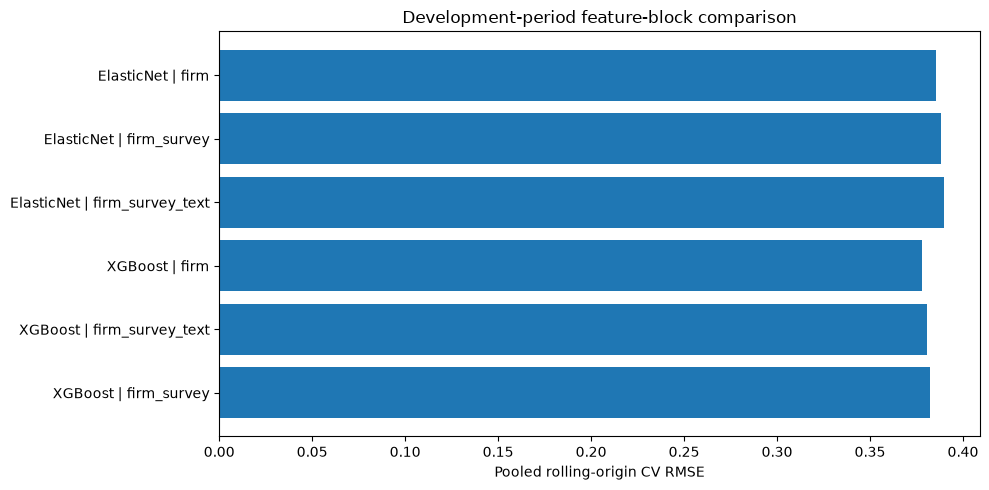

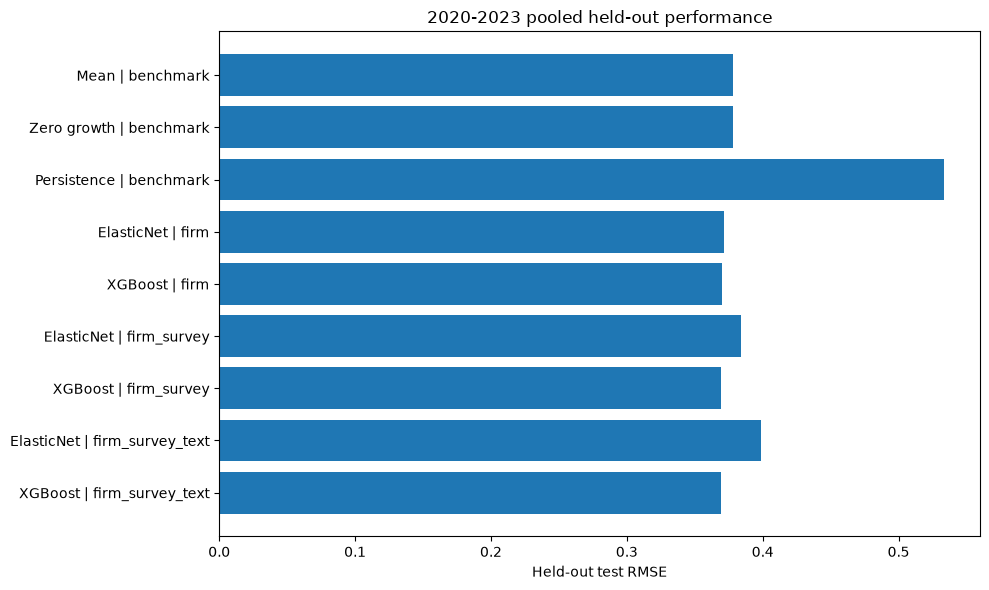

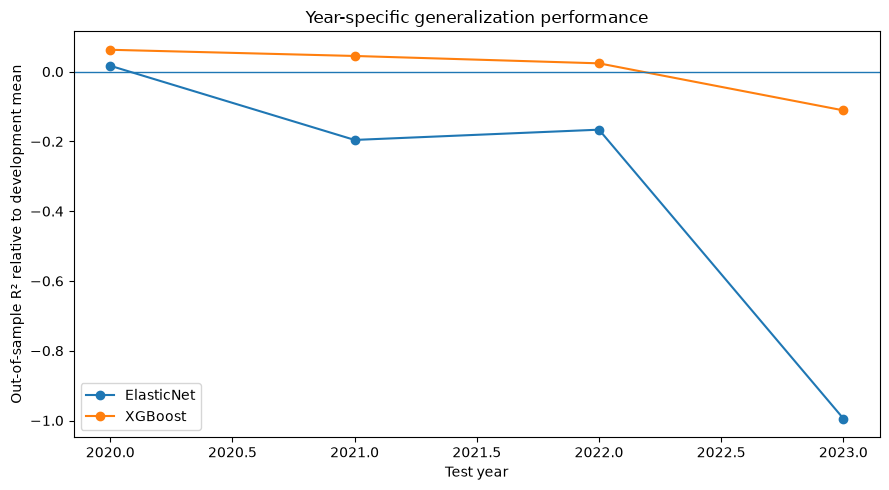

In [18]:
# Cross-validation ablation plot
plot_cv = ablation_cv.copy()
labels = plot_cv["model"] + " | " + plot_cv["feature_set"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, plot_cv["pooled_RMSE"])
ax.set_xlabel("Pooled rolling-origin CV RMSE")
ax.set_title("Development-period feature-block comparison")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

if not final_results.empty:
    pooled = final_results[final_results["scope"].eq("pooled")].copy()
    labels = pooled["model"] + " | " + pooled["feature_set"]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, pooled["RMSE"])
    ax.set_xlabel("Held-out test RMSE")
    ax.set_title("2020-2023 pooled held-out performance")
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

    yearly = final_results[
        final_results["scope"].eq("year")
        & final_results["model"].isin([BEST_LINEAR_FAMILY, "XGBoost"])
        & final_results["feature_set"].eq("firm_survey_text")
    ]
    fig, ax = plt.subplots(figsize=(9, 5))
    for model_name, group in yearly.groupby("model"):
        ax.plot(group["year"].astype(int), group["R2_oos"], marker="o", label=model_name)
    ax.axhline(0, linewidth=1)
    ax.set_xlabel("Test year")
    ax.set_ylabel("Out-of-sample R² relative to development mean")
    ax.set_title("Year-specific generalization performance")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 16. Save configuration and optional fitted models

In [19]:
configuration = {
    "data_path": str(DATA_PATH),
    "quick_mode": QUICK_MODE,
    "tuning_max_rows_per_year": TUNING_MAX_ROWS_PER_YEAR,
    "test_start_year": TEST_START_YEAR,
    "test_years": TEST_YEARS,
    "minimum_training_years": MIN_TRAIN_YEARS,
    "selected_linear_family": BEST_LINEAR_FAMILY,
    "selected_linear_parameters": BEST_LINEAR_PARAMS,
    "selected_xgb_parameters": BEST_XGB_PARAMS,
    "selected_xgb_n_estimators": BEST_XGB_N_ESTIMATORS,
    "feature_sets": FEATURE_SETS,
}
with open(OUTPUT_DIR / "run_configuration.json", "w", encoding="utf-8") as file:
    json.dump(configuration, file, indent=2, default=float)

if SAVE_MODELS and RUN_FINAL_TEST:
    if final_linear_full is not None:
        joblib.dump(final_linear_full, OUTPUT_DIR / "regularized_linear_full.joblib")
    if final_xgb_full is not None:
        final_xgb_full.save_model(OUTPUT_DIR / "xgboost_full.json")

print(f"Report outputs saved to: {OUTPUT_DIR.resolve()}")

Report outputs saved to: /workspaces/MLforEcon/outputs/time_aware_model_report


## 17. Recommended reporting sequence

Use the generated tables in this order:

1. Describe the 2010–2019 development and 2020–2023 held-out split.
2. Report rolling-origin CV performance and the selected hyperparameters.
3. Compare firm-only, firm-plus-survey, and full feature sets.
4. Report the held-out pooled score and scores by year.
5. State whether survey and text indicators reduce RMSE relative to the
   preceding feature block.
6. Use coefficient and importance tables only as descriptive evidence about
   predictive associations.

The most important substantive comparison is not simply Lasso versus XGBoost.
It is whether adding survey and text information improves genuine out-of-time
forecasts over firm fundamentals and simple benchmarks.